In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
from read_df import load_mcnu_data, load_evt_data


path = '../../Desktop/mc_MCP2025B_prodgenie_corsika_proton_rockbox_lowenergydirt_sbnd_CV_caf_flat_caf_sbnd_general_dfs.df'

mcnu_data   = load_mcnu_data(path, 1, n_chunks=1)
evt_data    = load_evt_data(path, chunk_i=0)

mcnu_ind = mcnu_data.index.to_frame()
evt_ind  = evt_data.index.to_frame()

print(evt_data.keys().tolist())


print("mcnu indexes")
print(mcnu_ind.columns)
print("---")
print("event indexes")
print(evt_ind.columns)
print("---")
print("event columns")
print(evt_data.columns.tolist())
#print(mcnu_ind["rec.mc.nu..index"].value_counts())
#print(evt_ind.head(20))
#print(evt_data["pfp"]["tindex"].head())
#print(evt_data)

Loading data...
Index(['firsttime', 'time', 'totalpe'], dtype='str')
  Chunk 0...
Non-zero POT entries : 3,828
Total MC POT         : 1.152e+19
Total events         : 88,138
  Chunk 0...
[('pfp', 'trk', 'producer', '', '', ''), ('pfp', 'trk', 'start', 'x', '', ''), ('pfp', 'trk', 'start', 'y', '', ''), ('pfp', 'trk', 'start', 'z', '', ''), ('pfp', 'trk', 'end', 'x', '', ''), ('pfp', 'trk', 'end', 'y', '', ''), ('pfp', 'trk', 'end', 'z', '', ''), ('pfp', 'trk', 'dir', 'x', '', ''), ('pfp', 'trk', 'dir', 'y', '', ''), ('pfp', 'trk', 'dir', 'z', '', ''), ('pfp', 'trk', 'len', '', '', ''), ('pfp', 'trk', 'rangeP', 'p_muon', '', ''), ('pfp', 'trk', 'mcsP', 'fwdP_muon', '', ''), ('pfp', 'trk', 'rangeP', 'p_pion', '', ''), ('pfp', 'trk', 'mcsP', 'fwdP_pion', '', ''), ('pfp', 'trk', 'rangeP', 'p_proton', '', ''), ('pfp', 'trk', 'mcsP', 'fwdP_proton', '', ''), ('pfp', 'trk', 'bestplane', '', '', ''), ('pfp', 'trk', 'crthit', 'distance', '', ''), ('pfp', 'trk', 'crthit', 'hit', 'time', ''), ('pf

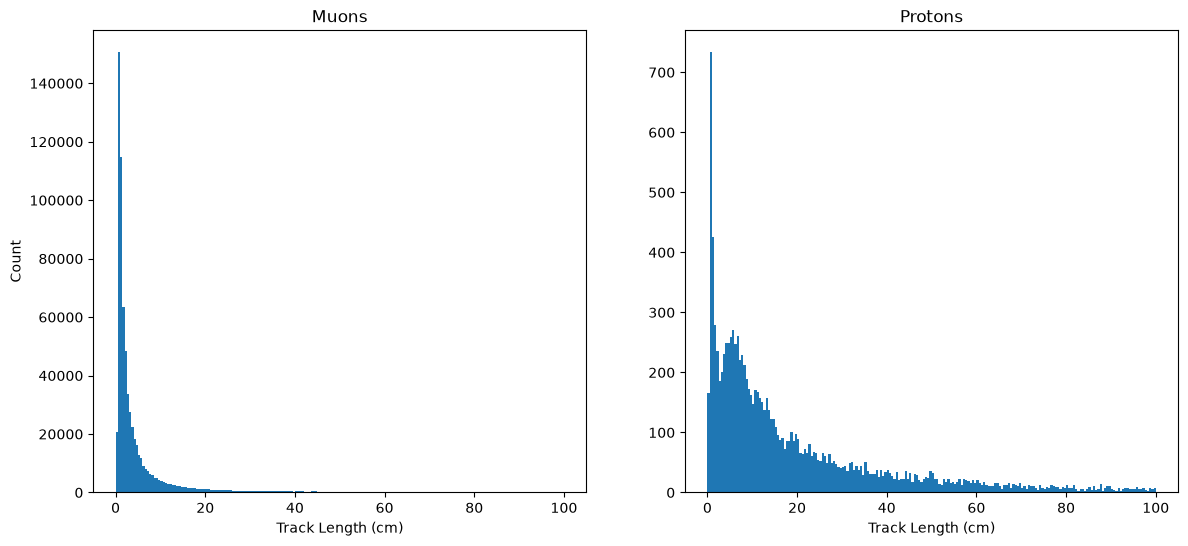

In [13]:

#print(evt_data.columns)
bins = np.linspace(0,100,201)
#print(primary_evt['pfp']['trk']['truth']['p']['pdg'].value_counts())
#print(evt_data['pfp']['trk']['truth']['p']['pdg'].value_counts())

evt_mu = evt_data[evt_data['pfp']['trk']['truth']['p']['pdg'] == 13]
evt_amu = evt_data[evt_data['pfp']['trk']['truth']['p']['pdg'] == -13]
evt_pr = evt_data[(evt_data['pfp']['trk']['truth']['p']['pdg'] == 2212) | (evt_data['pfp']['trk']['truth']['p']['pdg'] == -2212)]

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 6))
ax1.hist(evt_mu['pfp']['trk']['len'], bins=bins, label="muons")
ax2.hist(evt_pr['pfp']['trk']['len'], bins=bins, label="protons")
ax1.set_xlabel("Track Length (cm)")
ax2.set_xlabel("Track Length (cm)")
ax1.set_ylabel("Count")
ax1.set_title("Muons")
ax2.set_title("Protons")
plt.show()




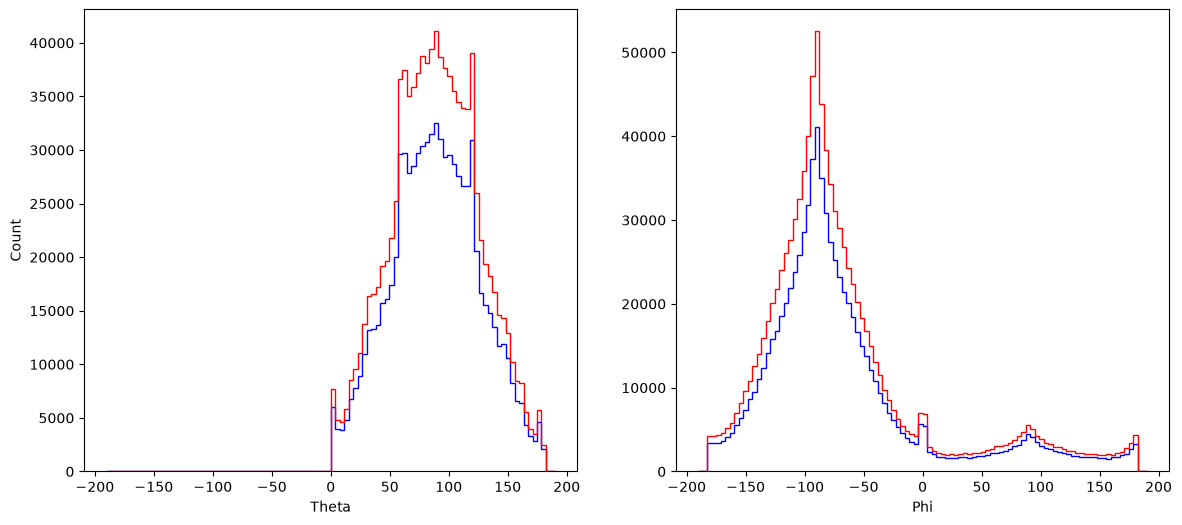

: 

: 

In [ ]:
bins = np.linspace(-190, 190, 101)

xs = evt_mu['pfp']['trk']['dir']['x']
ys = evt_mu['pfp']['trk']['dir']['y']
zs = evt_mu['pfp']['trk']['dir']['z']
thetas = np.degrees(np.atan2(np.sqrt(xs**2 + ys**2), zs))
phis   = np.degrees(np.atan2(ys, xs))

xs = evt_amu['pfp']['trk']['dir']['x']
ys = evt_amu['pfp']['trk']['dir']['y']
zs = evt_amu['pfp']['trk']['dir']['z']
a_thetas = np.degrees(np.atan2(np.sqrt(xs**2 + ys**2), zs))
a_phis   = np.degrees(np.atan2(ys, xs))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14, 6))
ax1.hist(thetas, bins=bins, label="muon", color="blue", histtype="step")
ax1.hist(a_thetas, bins=bins, label="anti muon", color="red", histtype="step")
ax2.hist(phis, bins=bins, label="muon", color="blue", histtype="step")
ax2.hist(a_phis, bins=bins, label="anti muon", color="red", histtype="step")
ax1.set_xlabel("Theta")
ax2.set_xlabel("Phi")
ax1.set_ylabel("Count")

plt.show()